<a href="https://colab.research.google.com/github/JohriSumati-ops/HEART-DISEASE-DETECTION-LINEAR-REGRESSION/blob/main/HEART_DISEASE_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
heart_df = pd.read_csv('/content/heart.csv')
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
heart_df.shape

(1025, 14)

In [ ]:
heart_df.isnull().sum()
heart_df.duplicated().sum()

np.int64(723)

In [ ]:
heart_df = heart_df.drop_duplicates()

In [ ]:
heart_df.shape

(302, 14)

In [ ]:
heart_df['target'].unique()

array([0, 1])

TRAIN TEST SPLIT

In [ ]:
X = heart_df.drop('target', axis=1)
y = heart_df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

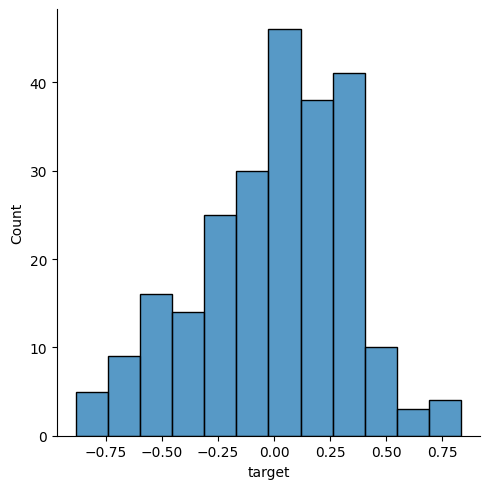

In [ ]:
sns.displot(y_train - model.predict(X_train))

values range from -0.75 to 0.75

In [ ]:
mse = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
np.mean(mse)

np.float64(-0.14227196262252995)

MODEL TRAINING AND PREDICTION

In [ ]:
pred = model.predict(X_test)

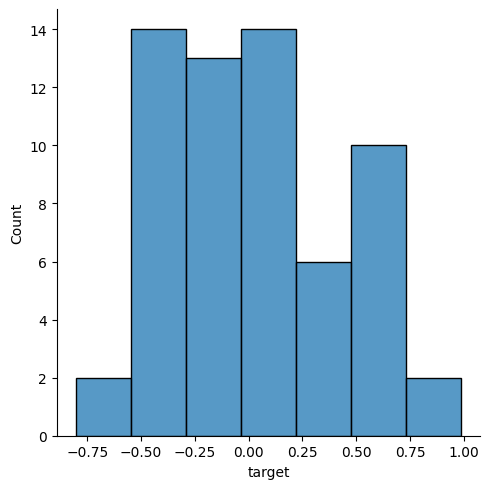

In [ ]:
sns.displot(pred-y_test)

In [ ]:
r2 = r2_score(y_test, pred)
print('R2 score:', r2)

R2 score: 0.3703864295198497


In [ ]:
import pickle

pickle.dump(model, open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
